# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Hilal Tsabitul Azmi Arba'i|5054251008|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


In [28]:
#%pip install --upgrade "numpy<2" "matplotlib>=3.8"

In [29]:
"""import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)"""

'import kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("yasserh/wine-quality-dataset")\n\nprint("Path to dataset files:", path)'

# 1. Persiapan Dataset & Eksplorasi Awal

In [30]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv("WineQT.csv")
data.head(20)

#print("max dari masing masing fitur:", data.max())
# Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [58]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [59]:
data["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

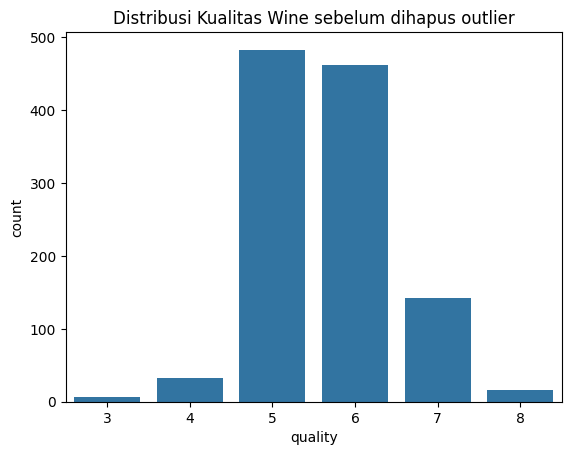

In [60]:
sns.countplot(x="quality", data=data)
plt.title("Distribusi Kualitas Wine sebelum dihapus outlier")
plt.show()

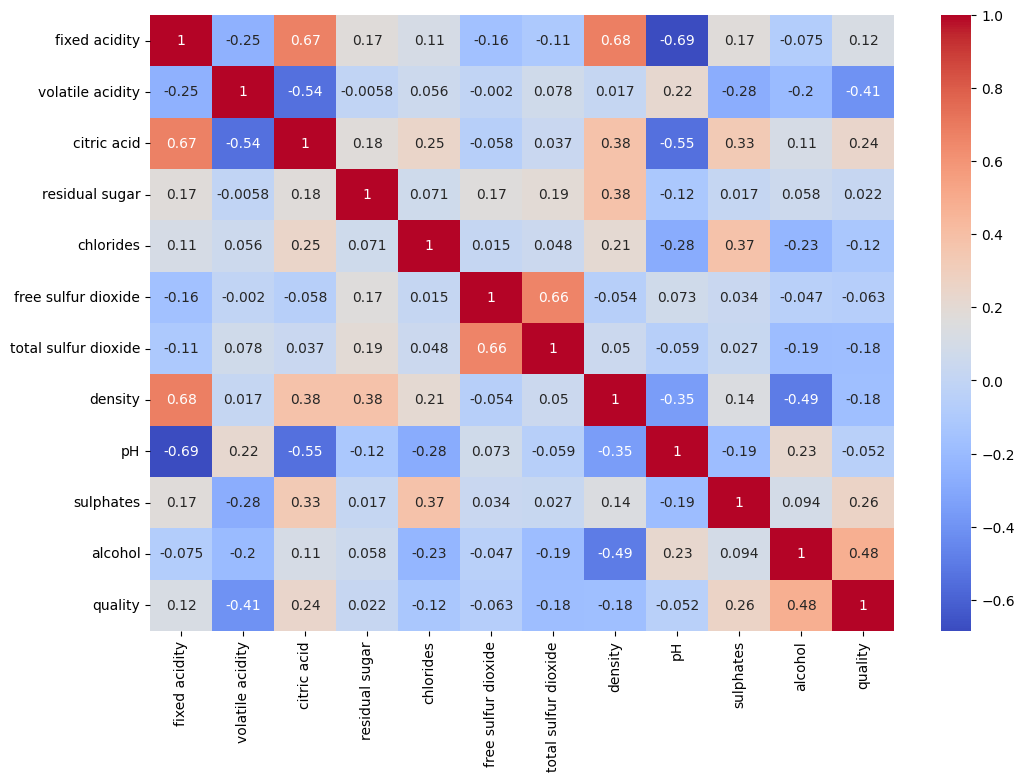

In [61]:
# Menghapus kolom Id karena hanya sebagai identitas data
corr_matrix = data.drop(columns=["Id"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

# Menampilkan nilai korelasi dalam bentuk tabel
plt.show()


In [62]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>,
        <Axes: title={'center': 'residual sugar'}>],
       [<Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>,
        <Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>],
       [<Axes: title={'center': 'Id'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

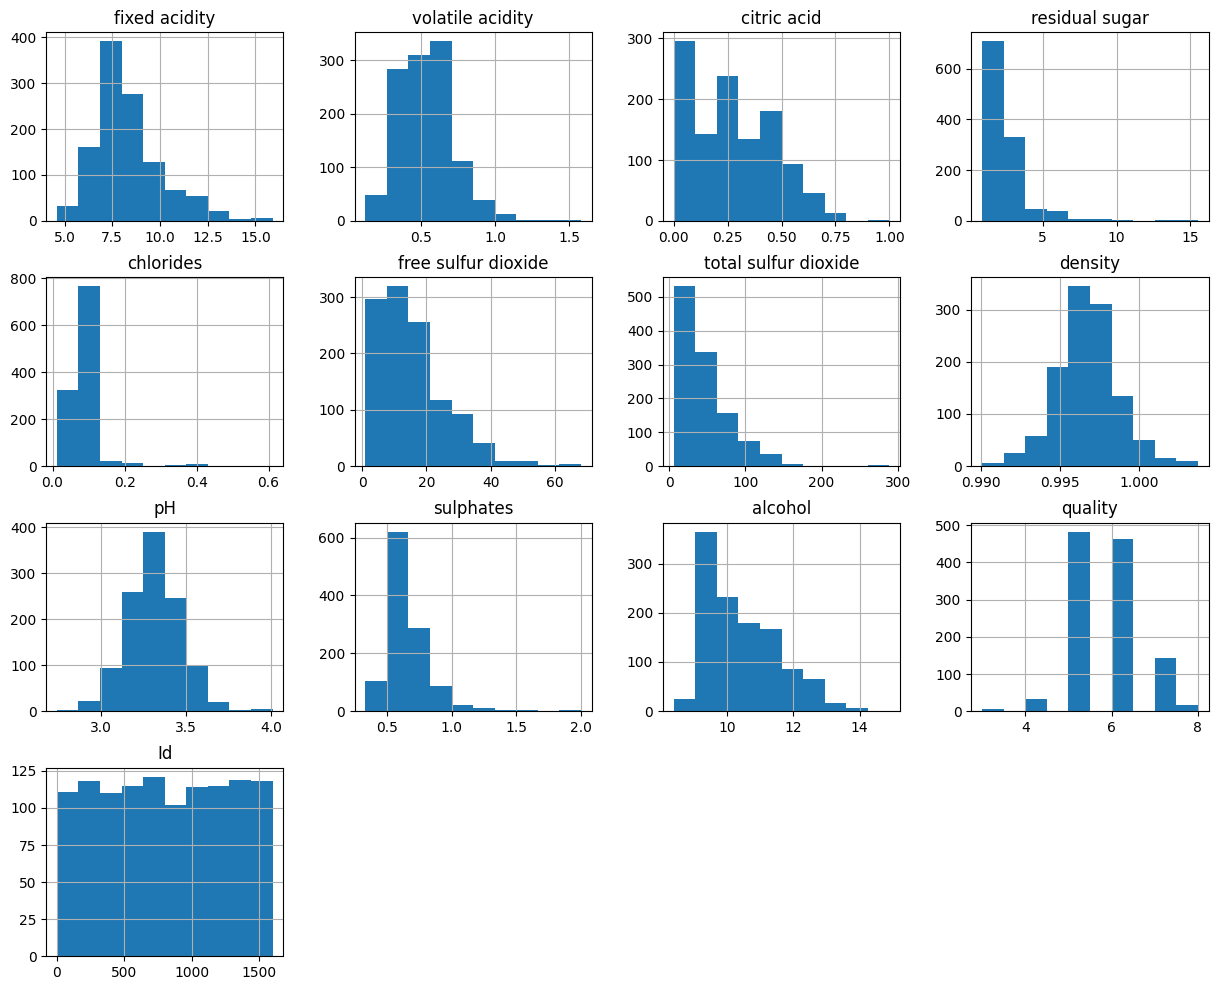

In [63]:
data.hist(figsize=(15, 12))

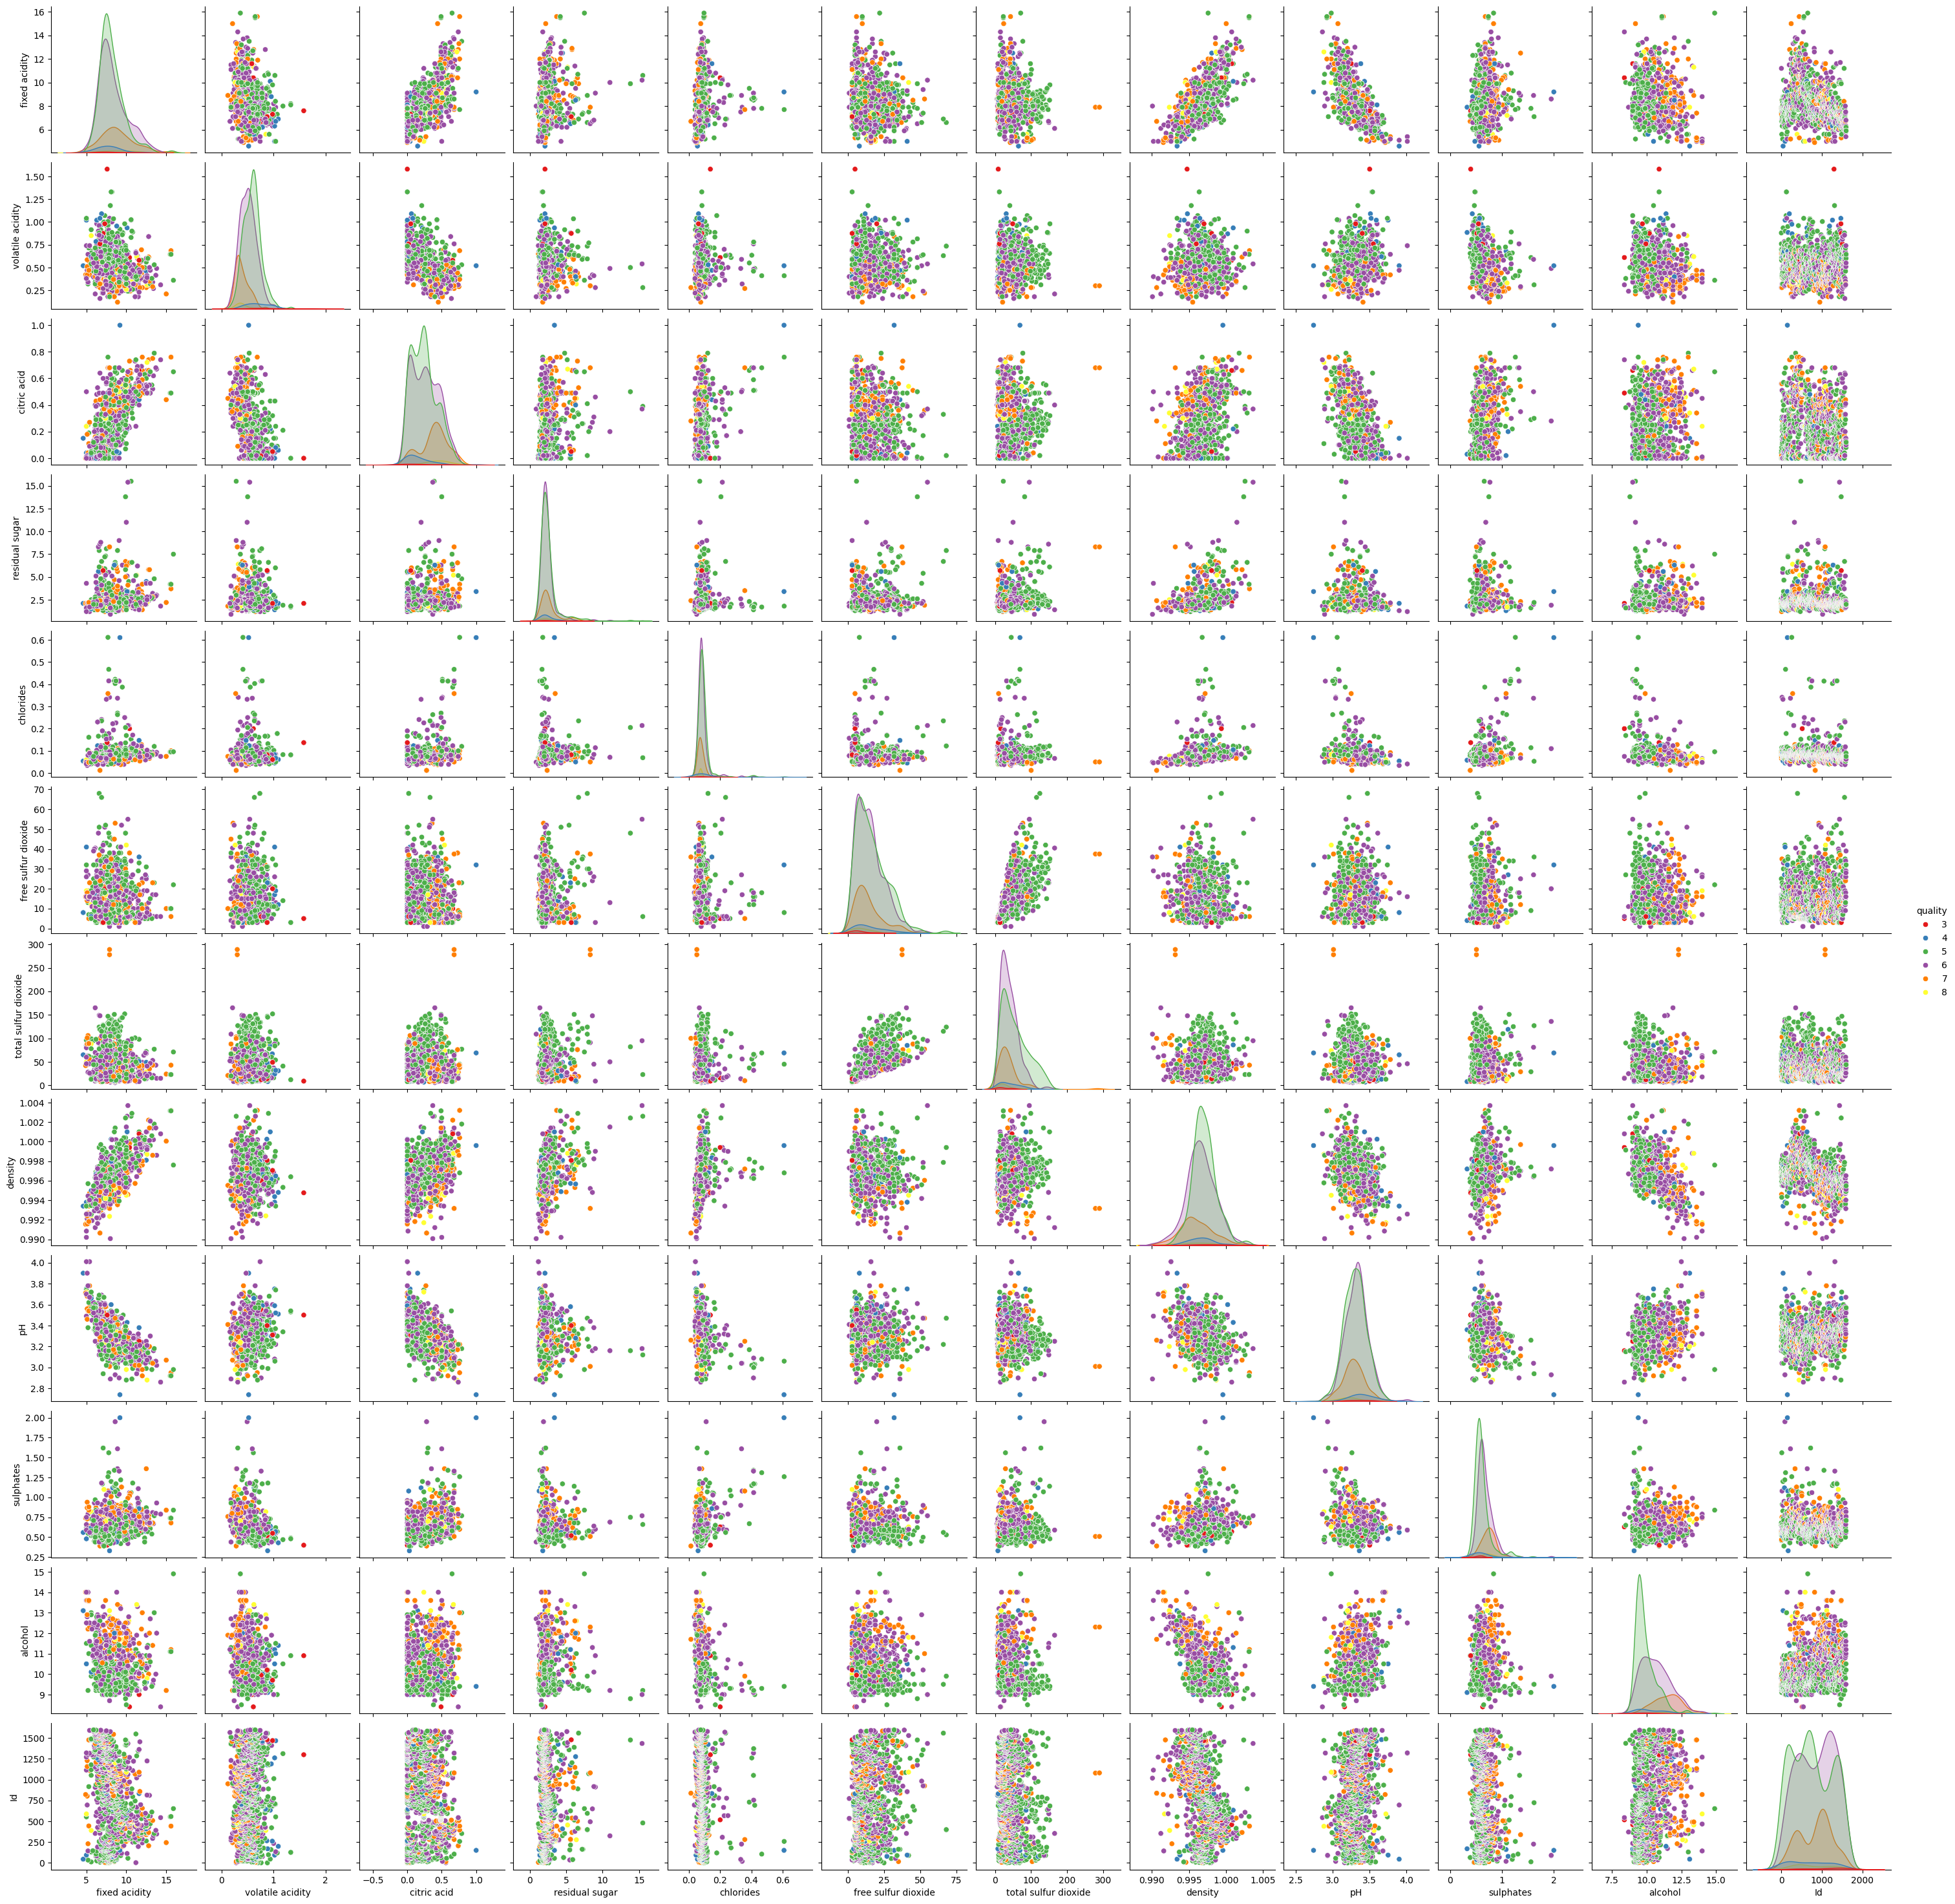

In [64]:
sns.pairplot(data, hue="quality", palette="Set1")


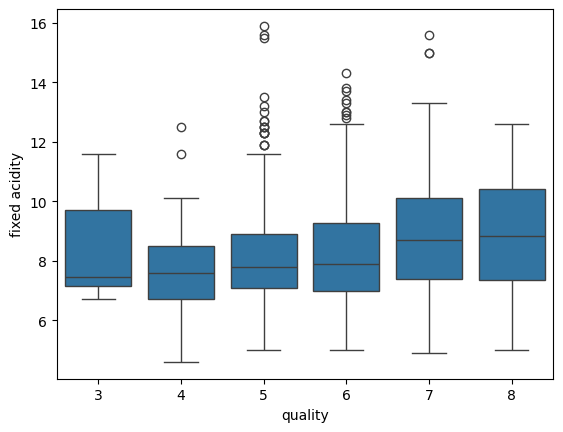

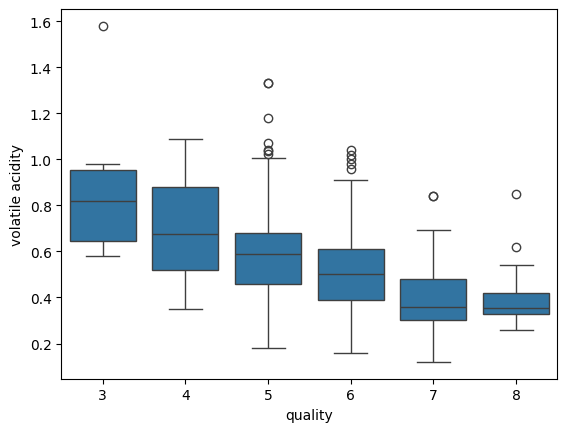

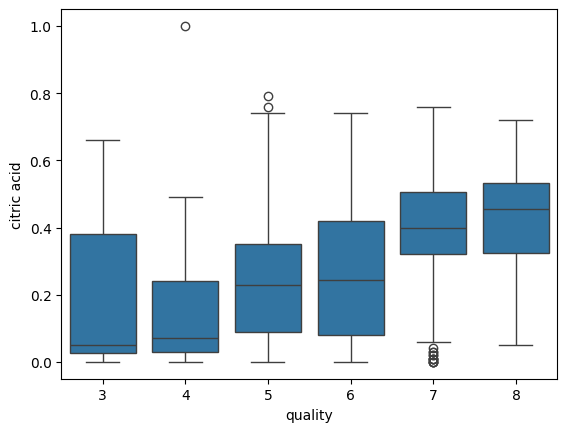

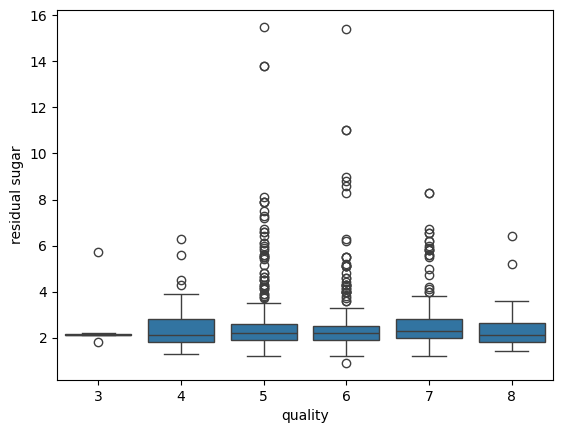

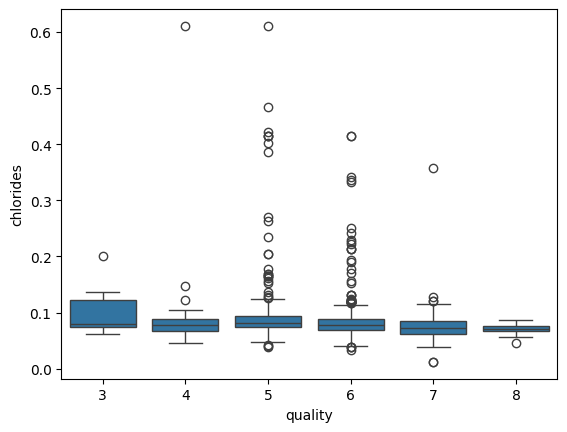

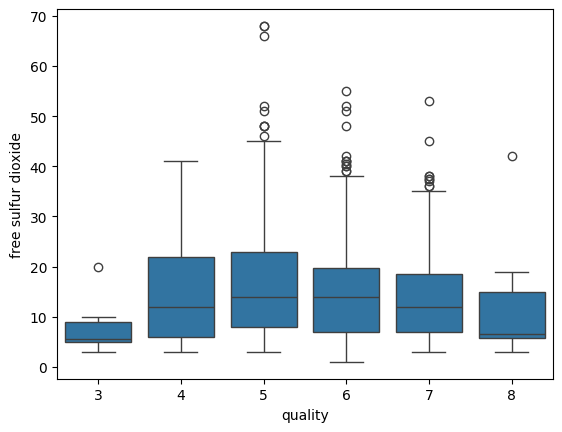

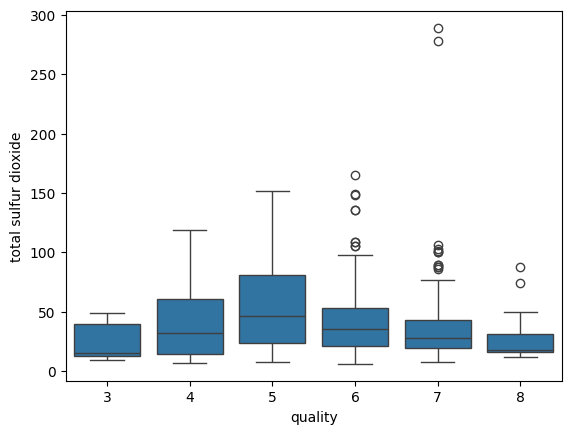

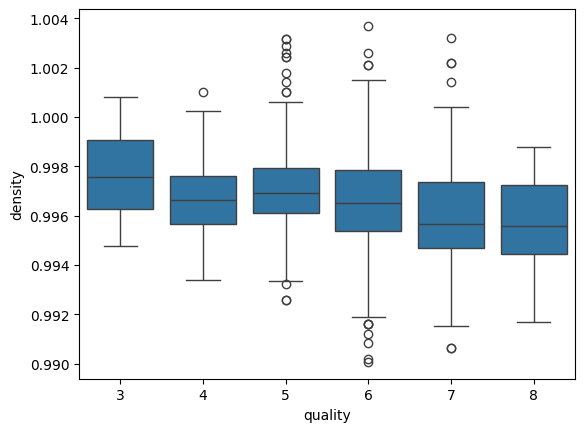

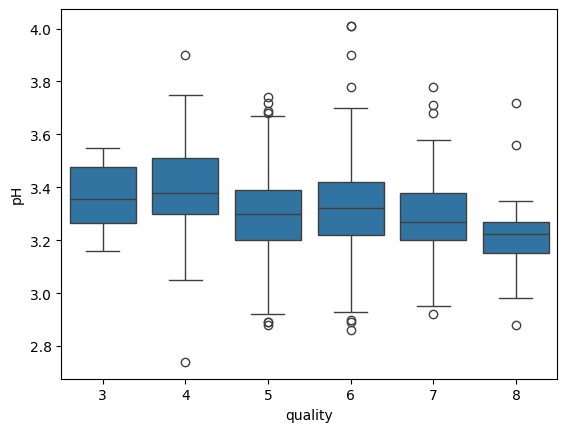

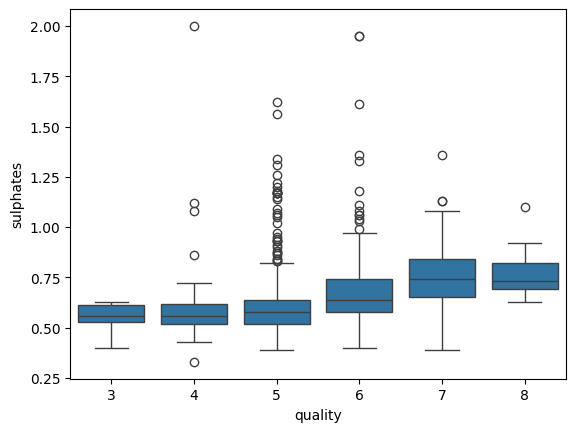

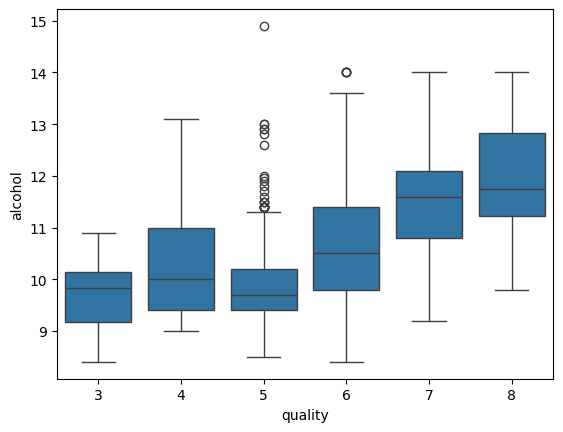

In [65]:
data = data.drop(columns=["Id"])        
for z in data.columns:
    if z != "quality":
        sns.boxplot(x="quality", y=z, data=data)
        plt.show()

In [66]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [69]:
data.duplicated().sum()

np.int64(125)

# 2. Preprocessing




In [70]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.
# Drop ID if it still exists; ignore if it was already removed earlier
data = data.drop(columns=["Id"], axis=1, errors="ignore")

# Handle missing values and duplicates defensively
data = data.dropna().reset_index(drop=True)
data = data.drop_duplicates().reset_index(drop=True)

In [71]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,8.288507,0.533541,0.268802,2.524411,0.087187,15.648821,46.325639,0.996700,3.311503,0.656817,10.452456,5.641454
std,1.741324,0.183167,0.196229,1.314850,0.048506,10.176525,33.123533,0.001916,0.157775,0.167542,1.095064,0.811744
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995572,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,38.000000,0.996665,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.645000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997827,3.400000,0.720000,11.200000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [72]:
data.duplicated().sum()

np.int64(0)

In [73]:
# # Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
# # import matplotlib.pyplot as plt
# # import pandas as pd
# # data = pd.read_csv("WineQT.csv")

# Q1 = data.quantile(0.25)
# Q3 = data.quantile(0.75)

# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
    
# data_cleaned = data[~((data < lower_bound) | (data > upper_bound)).any(axis=1)]

feature_columns = data.drop(
    columns=["quality", "Id"],
    errors="ignore"
).columns

Q1 = data[feature_columns].quantile(0.25)
Q3 = data[feature_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (data[feature_columns] < lower_bound) |
    (data[feature_columns] > upper_bound)
).any(axis=1)

data_cleaned = data.loc[~outlier_mask].copy()

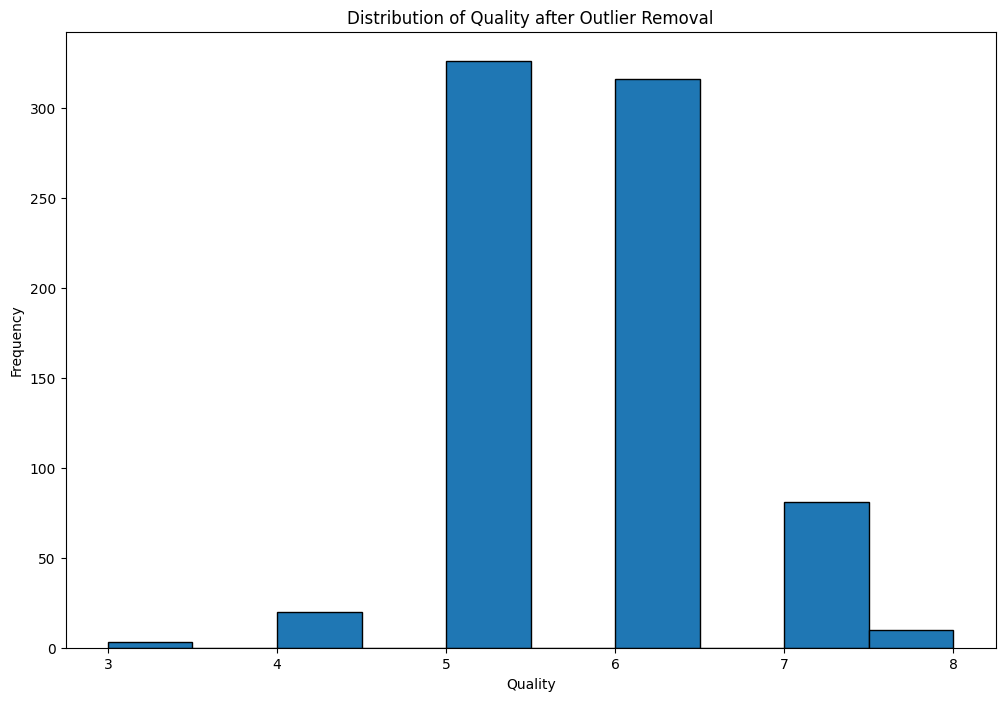

In [74]:
plt.figure(figsize=(12, 8))
plt.hist(data_cleaned["quality"], bins=10, edgecolor='black')
plt.title("Distribution of Quality after Outlier Removal")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

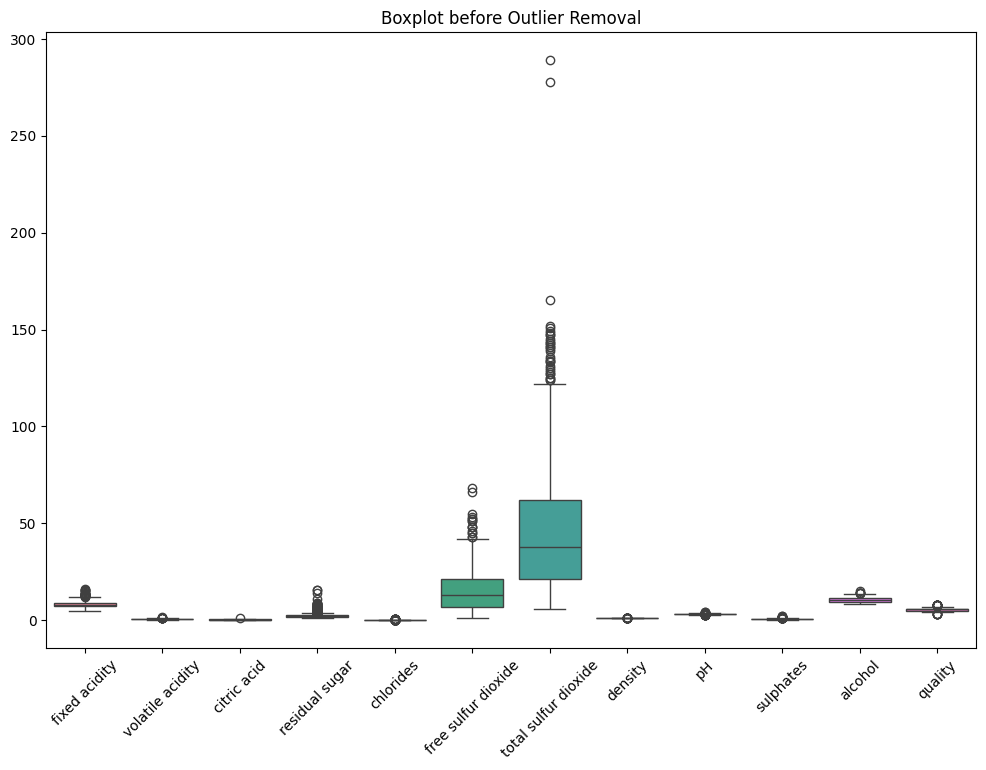

In [75]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplot before Outlier Removal")
plt.show()

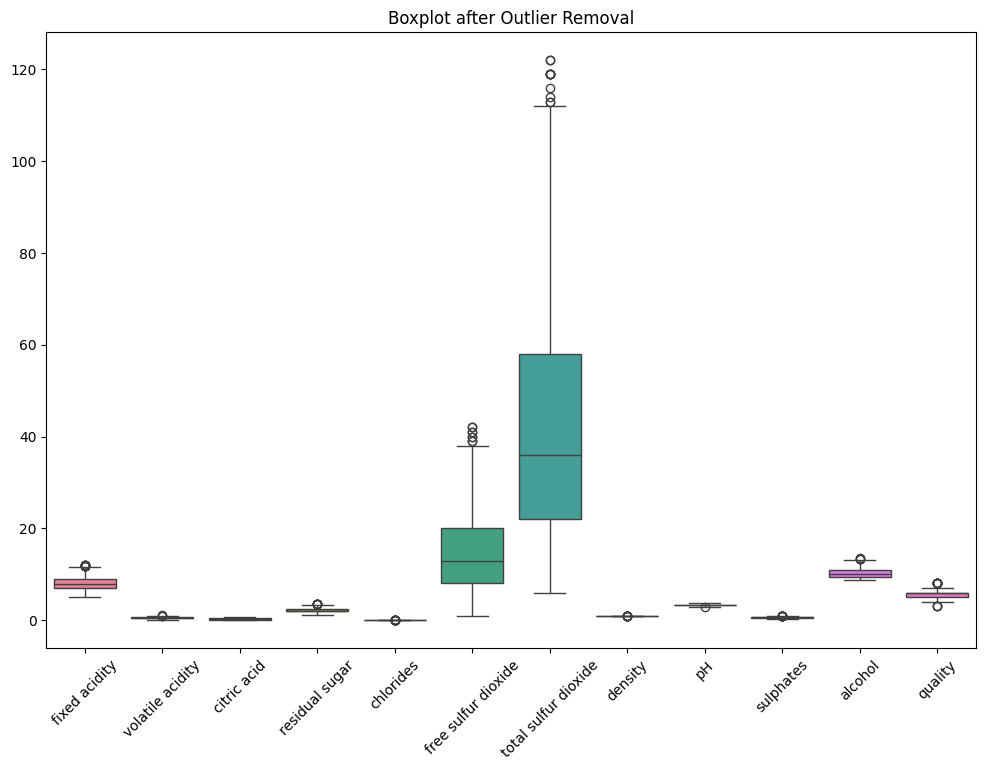

In [76]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data_cleaned)
plt.xticks(rotation=45)
plt.title("Boxplot after Outlier Removal")
plt.show()

In [77]:
print("Jumlah data sebelum outlier removal:", len(data))
print("Jumlah data setelah outlier removal:", len(data_cleaned))

Jumlah data sebelum outlier removal: 1018
Jumlah data setelah outlier removal: 756


In [78]:
X = data.drop(columns=["quality"], axis=1)
Y = data["quality"]

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [81]:
train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
test_data = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("describe train data:", train_data.describe())
print("describe test data:", test_data.describe())

describe train data:        fixed acidity  volatile acidity   citric acid  residual sugar  \
count   8.140000e+02      8.140000e+02  8.140000e+02    8.140000e+02   
mean    2.509595e-16     -6.328544e-17  7.419672e-17   -1.527580e-17   
std     1.000615e+00      1.000615e+00  1.000615e+00    1.000615e+00   
min    -2.161065e+00     -2.268500e+00 -1.399028e+00   -1.221034e+00   
25%    -7.035958e-01     -7.562583e-01 -8.855187e-01   -4.750706e-01   
50%    -2.372058e-01     -2.814208e-02 -6.390472e-02   -2.512816e-01   
75%     5.206781e-01      6.089596e-01  7.577093e-01    4.710384e-02   
max     4.426695e+00      5.908805e+00  3.736060e+00    9.670033e+00   

          chlorides  free sulfur dioxide  total sulfur dioxide       density  \
count  8.140000e+02         8.140000e+02          8.140000e+02  8.140000e+02   
mean   3.207917e-16         3.055159e-17         -6.546770e-17  3.115499e-14   
std    1.000615e+00         1.000615e+00          1.000615e+00  1.000615e+00   
min   -1.5

# 3. Eksperimen Model KNN


In [82]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

In [83]:
from sklearn.neighbors import KNeighborsClassifier

X = data.drop(columns=["quality"], axis=1)
Y = data["quality"]

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
test_data = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# print("describe train data:", train_data.describe())
# print("describe test data:", test_data.describe())

print("Menggunakan data yang belum di remove outlier")
for z in range(1, 20):
    knn = KNeighborsClassifier(
        n_neighbors=z,
        metric='euclidean'
    )

    knn.fit(X_train_scaled, Y_train)
    train_acc = knn.score(X_train_scaled, Y_train)

    test_acc = knn.score(X_test_scaled, Y_test)
    print(f"n_neighbors: {z}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)
    

Menggunakan data yang belum di remove outlier
n_neighbors: 1
Train Accuracy: 1.0
Test Accuracy : 0.5147058823529411
n_neighbors: 2
Train Accuracy: 0.7714987714987716
Test Accuracy : 0.5490196078431373
n_neighbors: 3
Train Accuracy: 0.7346437346437347
Test Accuracy : 0.5098039215686274
n_neighbors: 4
Train Accuracy: 0.7002457002457002
Test Accuracy : 0.5784313725490197
n_neighbors: 5
Train Accuracy: 0.6781326781326781
Test Accuracy : 0.5588235294117647
n_neighbors: 6
Train Accuracy: 0.6633906633906634
Test Accuracy : 0.5637254901960784
n_neighbors: 7
Train Accuracy: 0.6547911547911548
Test Accuracy : 0.5686274509803921
n_neighbors: 8
Train Accuracy: 0.6572481572481572
Test Accuracy : 0.5490196078431373
n_neighbors: 9
Train Accuracy: 0.6474201474201474
Test Accuracy : 0.5784313725490197
n_neighbors: 10
Train Accuracy: 0.6474201474201474
Test Accuracy : 0.5637254901960784
n_neighbors: 11
Train Accuracy: 0.6461916461916462
Test Accuracy : 0.5784313725490197
n_neighbors: 12
Train Accuracy: 

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_remove_IQR = data_cleaned.drop(columns=["quality"], axis=1)
Y_remove_IQR = data_cleaned["quality"]

X_train_IQR, X_test_IQR, Y_train_IQR, Y_test_IQR = train_test_split(
    X_remove_IQR,
    Y_remove_IQR,
    test_size=0.2,
    random_state=42,
    stratify=Y_remove_IQR
)

scaler = StandardScaler()
X_train_IQR_scaled = scaler.fit_transform(X_train_IQR)
X_test_IQR_scaled = scaler.transform(X_test_IQR)

train_data = pd.DataFrame(X_train_IQR_scaled, columns=X_train_IQR.columns)
test_data = pd.DataFrame(X_test_IQR_scaled, columns=X_test_IQR.columns)

# print("describe train data:", train_data.describe())
# print("describe test data:", test_data.describe())
print("enggunakan data yang sudah di remove outlier")

for z in range(1, 20):
    knn = KNeighborsClassifier(
        n_neighbors=z,
        metric='euclidean'
    )

    knn.fit(X_train_IQR_scaled, Y_train_IQR)
    train_acc = knn.score(X_train_IQR_scaled, Y_train_IQR)
    
    test_acc = knn.score(X_test_IQR_scaled, Y_test_IQR)
    print(f"n_neighbors: {z}")
    print("Train Accuracy:", train_acc)
    print("Test Accuracy :", test_acc)

enggunakan data yang sudah di remove outlier
n_neighbors: 1
Train Accuracy: 1.0
Test Accuracy : 0.4868421052631579
n_neighbors: 2
Train Accuracy: 0.7665562913907285
Test Accuracy : 0.5131578947368421
n_neighbors: 3
Train Accuracy: 0.7433774834437086
Test Accuracy : 0.5789473684210527
n_neighbors: 4
Train Accuracy: 0.7235099337748344
Test Accuracy : 0.6052631578947368
n_neighbors: 5
Train Accuracy: 0.6937086092715232
Test Accuracy : 0.5592105263157895
n_neighbors: 6
Train Accuracy: 0.7052980132450332
Test Accuracy : 0.5789473684210527
n_neighbors: 7
Train Accuracy: 0.6821192052980133
Test Accuracy : 0.5723684210526315
n_neighbors: 8
Train Accuracy: 0.6870860927152318
Test Accuracy : 0.5657894736842105
n_neighbors: 9
Train Accuracy: 0.6837748344370861
Test Accuracy : 0.5394736842105263
n_neighbors: 10
Train Accuracy: 0.6589403973509934
Test Accuracy : 0.5986842105263158
n_neighbors: 11
Train Accuracy: 0.6473509933774835
Test Accuracy : 0.5986842105263158
n_neighbors: 12
Train Accuracy: 0

In [85]:
distribution_before = (
    data["quality"]
    .value_counts()
    .sort_index()
)

distribution_after = (
    data_cleaned["quality"]
    .value_counts()
    .sort_index()
)

distribution_comparison = pd.DataFrame({
    "Before Removal": distribution_before,
    "After Removal": distribution_after
}).fillna(0).astype(int)

distribution_comparison["Removed"] = (
    distribution_comparison["Before Removal"]
    - distribution_comparison["After Removal"]
)

distribution_comparison["Removal Percentage"] = (
    distribution_comparison["Removed"]
    / distribution_comparison["Before Removal"]
    * 100
).round(2)

distribution_comparison

,Before Removal,After Removal,Removed,Removal Percentage
quality,,,,
3,6,3,3,50.00
4,33,20,13,39.39
5,433,326,107,24.71
6,409,316,93,22.74
7,122,81,41,33.61
8,15,10,5,33.33


In [116]:
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_knn_range(
    X_train,
    X_test,
    y_train,
    y_test,
    dataset_name,
    metric
):
    results = []

    for k in range(1, 20):
        model = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        results.append({
            "Dataset": dataset_name,
            "Metric": metric,
            "K": k,

            "Train Accuracy": accuracy_score(
                y_train,
                y_train_pred
            ),

            "Test Accuracy": accuracy_score(
                y_test,
                y_test_pred
            ),

            "Macro Precision": precision_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0
            ),

            "Macro Recall": recall_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0
            ),

            "Macro F1": f1_score(
                y_test,
                y_test_pred,
                average="macro",
                zero_division=0
            ),

            "Weighted F1": f1_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0
            )
        })

    results_df = pd.DataFrame(results)

    results_df["Gap"] = (
        results_df["Train Accuracy"]
        - results_df["Test Accuracy"]
    )

    return results_df

In [117]:
results_before_euclidean = evaluate_knn_range(
    X_train_scaled,
    X_test_scaled,
    Y_train,
    Y_test,
    dataset_name="data",
    metric="euclidean"
)
results_before_euclidean

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data,euclidean,1,1.000000,0.514706,0.274717,0.288061,0.279641,0.518733,0.485294
1,data,euclidean,2,0.771499,0.549020,0.303439,0.276093,0.278513,0.539032,0.222479
2,data,euclidean,3,0.734644,0.509804,0.266869,0.266731,0.265251,0.512166,0.224840
3,data,euclidean,4,0.700246,0.578431,0.313231,0.293667,0.300056,0.567604,0.121814
4,data,euclidean,5,0.678133,0.558824,0.277239,0.279314,0.277994,0.549800,0.119309
5,data,euclidean,6,0.663391,0.563725,0.269530,0.270705,0.268857,0.550690,0.099665
6,data,euclidean,7,0.654791,0.568627,0.276096,0.283379,0.279387,0.559271,0.086164
7,data,euclidean,8,0.657248,0.549020,0.264372,0.260279,0.260723,0.536101,0.108229
8,data,euclidean,9,0.647420,0.578431,0.278529,0.272475,0.272575,0.562681,0.068989
9,data,euclidean,10,0.647420,0.563725,0.268834,0.266377,0.265696,0.548454,0.083695


In [118]:
results_after_euclidean = evaluate_knn_range(
    X_train_IQR_scaled,
    X_test_IQR_scaled,
    Y_train_IQR,
    Y_test_IQR,
    dataset_name="data_cleaned",
    metric="euclidean"
)
results_after_euclidean

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data_cleaned,euclidean,1,1.000000,0.486842,0.266445,0.302730,0.277274,0.484919,0.513158
1,data_cleaned,euclidean,2,0.766556,0.513158,0.256372,0.223770,0.227690,0.497964,0.253398
2,data_cleaned,euclidean,3,0.743377,0.578947,0.276673,0.258718,0.262505,0.566818,0.164430
3,data_cleaned,euclidean,4,0.723510,0.605263,0.265059,0.260567,0.258585,0.582829,0.118247
4,data_cleaned,euclidean,5,0.693709,0.559211,0.238597,0.243010,0.240084,0.545934,0.134498
5,data_cleaned,euclidean,6,0.705298,0.578947,0.253036,0.258357,0.255325,0.565751,0.126351
6,data_cleaned,euclidean,7,0.682119,0.572368,0.243723,0.247941,0.244108,0.551502,0.109751
7,data_cleaned,euclidean,8,0.687086,0.565789,0.236519,0.237765,0.232945,0.540532,0.121297
8,data_cleaned,euclidean,9,0.683775,0.539474,0.222821,0.227062,0.222108,0.515472,0.144301
9,data_cleaned,euclidean,10,0.658940,0.598684,0.260872,0.258643,0.255686,0.574702,0.060256


In [119]:
results_before_manhattan = evaluate_knn_range(
    X_train_scaled,
    X_test_scaled,
    Y_train,
    Y_test,
    dataset_name="data",
    metric="manhattan"
)
results_before_manhattan

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data,manhattan,1,1.000000,0.514706,0.273060,0.283149,0.276751,0.519620,0.485294
1,data,manhattan,2,0.765356,0.529412,0.305417,0.268314,0.273475,0.518178,0.235945
2,data,manhattan,3,0.729730,0.470588,0.247671,0.245559,0.244903,0.470958,0.259141
3,data,manhattan,4,0.708845,0.495098,0.253730,0.249875,0.250750,0.487313,0.213747
4,data,manhattan,5,0.687961,0.480392,0.236150,0.232875,0.233384,0.470446,0.207569
5,data,manhattan,6,0.662162,0.544118,0.267183,0.258130,0.259367,0.527092,0.118045
6,data,manhattan,7,0.664619,0.553922,0.266255,0.267691,0.265807,0.539771,0.110698
7,data,manhattan,8,0.663391,0.539216,0.256410,0.261243,0.258241,0.524512,0.124175
8,data,manhattan,9,0.651106,0.544118,0.262801,0.258831,0.258065,0.529254,0.106988
9,data,manhattan,10,0.646192,0.514706,0.244761,0.246636,0.244598,0.501259,0.131486


In [120]:
results_after_manhattan = evaluate_knn_range(
    X_train_IQR_scaled,
    X_test_IQR_scaled,
    Y_train_IQR,
    Y_test_IQR,
    dataset_name="data_cleaned",
    metric="manhattan"
)
results_after_manhattan

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data_cleaned,manhattan,1,1.000000,0.519737,0.285880,0.323368,0.297275,0.518149,0.480263
1,data_cleaned,manhattan,2,0.758278,0.513158,0.253724,0.223530,0.225833,0.493769,0.245120
2,data_cleaned,manhattan,3,0.723510,0.486842,0.246362,0.222162,0.229547,0.483055,0.236668
3,data_cleaned,manhattan,4,0.725166,0.565789,0.262245,0.252946,0.253486,0.547860,0.159376
4,data_cleaned,manhattan,5,0.687086,0.552632,0.244387,0.240605,0.239954,0.537449,0.134455
5,data_cleaned,manhattan,6,0.703642,0.572368,0.259481,0.255952,0.255675,0.556884,0.131274
6,data_cleaned,manhattan,7,0.677152,0.605263,0.269074,0.269060,0.266715,0.584917,0.071889
7,data_cleaned,manhattan,8,0.688742,0.611842,0.275133,0.271224,0.269665,0.589093,0.076900
8,data_cleaned,manhattan,9,0.673841,0.598684,0.260027,0.258162,0.255023,0.573614,0.075157
9,data_cleaned,manhattan,10,0.675497,0.625000,0.275223,0.268503,0.265679,0.597283,0.050497


In [121]:
best_test_accuracy_before_euclidean = results_before_euclidean.loc[
    results_before_euclidean
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

smallest_gap_before_euclidean = results_before_euclidean.loc[
    results_before_euclidean   
    .groupby("Dataset")["Gap"]
    .idxmin()
]

print("Best test accuracy sebelum outlier removal (Euclidean):")
print(best_test_accuracy_before_euclidean)

print("\nSmallest gap sebelum outlier removal (Euclidean):")
print(smallest_gap_before_euclidean)

Best test accuracy sebelum outlier removal (Euclidean):
   Dataset     Metric   K  Train Accuracy  Test Accuracy  Macro Precision  \
18    data  euclidean  19        0.604423       0.598039         0.290747   

    Macro Recall  Macro F1  Weighted F1       Gap  
18      0.280137  0.280756     0.577276  0.006383  

Smallest gap sebelum outlier removal (Euclidean):
   Dataset     Metric   K  Train Accuracy  Test Accuracy  Macro Precision  \
18    data  euclidean  19        0.604423       0.598039         0.290747   

    Macro Recall  Macro F1  Weighted F1       Gap  
18      0.280137  0.280756     0.577276  0.006383  


In [122]:
best_test_accuracy_after_euclidean = results_after_euclidean.loc[
    results_after_euclidean
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

smallest_gap_after_euclidean = results_after_euclidean.loc[
    results_after_euclidean     
    .groupby("Dataset")["Gap"]
    .idxmin()
]

print("Best test accuracy setelah outlier removal (Euclidean):")
print(best_test_accuracy_after_euclidean)

print("\nSmallest gap setelah outlier removal (Euclidean):")
print(smallest_gap_after_euclidean)

Best test accuracy setelah outlier removal (Euclidean):
         Dataset     Metric   K  Train Accuracy  Test Accuracy  \
14  data_cleaned  euclidean  15        0.652318       0.611842   

    Macro Precision  Macro Recall  Macro F1  Weighted F1       Gap  
14         0.280858      0.270863  0.269913     0.586152  0.040476  

Smallest gap setelah outlier removal (Euclidean):
         Dataset     Metric   K  Train Accuracy  Test Accuracy  \
12  data_cleaned  euclidean  13        0.625828       0.592105   

    Macro Precision  Macro Recall  Macro F1  Weighted F1       Gap  
12         0.281857      0.263408  0.264858     0.568747  0.033723  


In [123]:
best_test_accuracy_before_manhattan = results_before_manhattan.loc[
    results_before_manhattan
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

best_test_accuracy_before_manhattan = results_before_manhattan.loc[
    results_before_manhattan
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

print("Best test accuracy sebelum outlier removal (Manhattan):")
print(best_test_accuracy_before_manhattan)

print("\nBest test accuracy sebelum outlier removal (Manhattan):")
print(best_test_accuracy_before_manhattan)

Best test accuracy sebelum outlier removal (Manhattan):
   Dataset     Metric   K  Train Accuracy  Test Accuracy  Macro Precision  \
18    data  manhattan  19        0.614251       0.578431         0.278772   

    Macro Recall  Macro F1  Weighted F1       Gap  
18      0.281948  0.279354     0.560843  0.035819  

Best test accuracy sebelum outlier removal (Manhattan):
   Dataset     Metric   K  Train Accuracy  Test Accuracy  Macro Precision  \
18    data  manhattan  19        0.614251       0.578431         0.278772   

    Macro Recall  Macro F1  Weighted F1       Gap  
18      0.281948  0.279354     0.560843  0.035819  


In [124]:
best_test_accuracy_after_manhattan = results_after_manhattan.loc[
    results_after_manhattan
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

best_test_accuracy_after_manhattan = results_after_manhattan.loc[
    results_after_manhattan
    .groupby("Dataset")["Test Accuracy"]
    .idxmax()
]

print("Best test accuracy setelah outlier removal (Manhattan):")
print(best_test_accuracy_after_manhattan) 

print("\nBest test accuracy setelah outlier removal (Manhattan):")
print(best_test_accuracy_after_manhattan)

Best test accuracy setelah outlier removal (Manhattan):
         Dataset     Metric   K  Train Accuracy  Test Accuracy  \
12  data_cleaned  manhattan  13        0.653974       0.631579   

    Macro Precision  Macro Recall  Macro F1  Weighted F1       Gap  
12         0.284759      0.271149   0.26923     0.602946  0.022395  

Best test accuracy setelah outlier removal (Manhattan):
         Dataset     Metric   K  Train Accuracy  Test Accuracy  \
12  data_cleaned  manhattan  13        0.653974       0.631579   

    Macro Precision  Macro Recall  Macro F1  Weighted F1       Gap  
12         0.284759      0.271149   0.26923     0.602946  0.022395  


# 4. Evaluasi Model


In [ ]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

In [145]:
all_results = pd.concat([
    results_before_euclidean,
    results_after_euclidean,
    results_before_manhattan,
    results_after_manhattan
    ], ignore_index= True
)
                  
all_results

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data,euclidean,1,1.000000,0.514706,0.274717,0.288061,0.279641,0.518733,0.485294
1,data,euclidean,2,0.771499,0.549020,0.303439,0.276093,0.278513,0.539032,0.222479
2,data,euclidean,3,0.734644,0.509804,0.266869,0.266731,0.265251,0.512166,0.224840
3,data,euclidean,4,0.700246,0.578431,0.313231,0.293667,0.300056,0.567604,0.121814
4,data,euclidean,5,0.678133,0.558824,0.277239,0.279314,0.277994,0.549800,0.119309
...,...,...,...,...,...,...,...,...,...,...
71,data_cleaned,manhattan,15,0.650662,0.618421,0.279905,0.265858,0.264098,0.590086,0.032241
72,data_cleaned,manhattan,16,0.632450,0.605263,0.275242,0.260687,0.259265,0.577890,0.027187
73,data_cleaned,manhattan,17,0.624172,0.611842,0.280532,0.270863,0.269914,0.586249,0.012330
74,data_cleaned,manhattan,18,0.627483,0.598684,0.275783,0.265813,0.265428,0.574837,0.028799


In [146]:
best_macro_f1= (
    all_results.sort_values(by="Macro F1", ascending=False)
    .head(10)
    
)
best_macro_f1[display_columns].round(4)

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
3,data,euclidean,4,0.7002,0.5784,0.3132,0.2937,0.3001,0.5676,0.1218
57,data_cleaned,manhattan,1,1.0000,0.5197,0.2859,0.3234,0.2973,0.5181,0.4803
18,data,euclidean,19,0.6044,0.5980,0.2907,0.2801,0.2808,0.5773,0.0064
0,data,euclidean,1,1.0000,0.5147,0.2747,0.2881,0.2796,0.5187,0.4853
6,data,euclidean,7,0.6548,0.5686,0.2761,0.2834,0.2794,0.5593,0.0862
56,data,manhattan,19,0.6143,0.5784,0.2788,0.2819,0.2794,0.5608,0.0358
1,data,euclidean,2,0.7715,0.5490,0.3034,0.2761,0.2785,0.5390,0.2225
10,data,euclidean,11,0.6462,0.5784,0.2854,0.2774,0.2782,0.5624,0.0678
12,data,euclidean,13,0.6216,0.5833,0.2976,0.2743,0.2782,0.5640,0.0383
4,data,euclidean,5,0.6781,0.5588,0.2772,0.2793,0.2780,0.5498,0.1193


In [147]:
best_accuracy= (
    all_results.sort_values(by="Test Accuracy", ascending=False)
    .head(10)
)
best_accuracy.round(4)

,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
69,data_cleaned,manhattan,13,0.6540,0.6316,0.2848,0.2711,0.2692,0.6029,0.0224
66,data_cleaned,manhattan,10,0.6755,0.6250,0.2752,0.2685,0.2657,0.5973,0.0505
67,data_cleaned,manhattan,11,0.6556,0.6184,0.2727,0.2660,0.2633,0.5914,0.0372
70,data_cleaned,manhattan,14,0.6540,0.6184,0.2915,0.2740,0.2751,0.5948,0.0356
71,data_cleaned,manhattan,15,0.6507,0.6184,0.2799,0.2659,0.2641,0.5901,0.0322
68,data_cleaned,manhattan,12,0.6540,0.6118,0.2777,0.2633,0.2619,0.5844,0.0421
33,data_cleaned,euclidean,15,0.6523,0.6118,0.2809,0.2709,0.2699,0.5862,0.0405
73,data_cleaned,manhattan,17,0.6242,0.6118,0.2805,0.2709,0.2699,0.5862,0.0123
64,data_cleaned,manhattan,8,0.6887,0.6118,0.2751,0.2712,0.2697,0.5891,0.0769
72,data_cleaned,manhattan,16,0.6325,0.6053,0.2752,0.2607,0.2593,0.5779,0.0272


In [148]:
display_columns = [
    "Dataset",
    "Metric",
    "K",
    "Train Accuracy",
    "Test Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
    "Gap"
]

candidate_indices = (
    all_results
    .groupby(
        ["Dataset", "Metric"]
    )["Macro F1"]
    .idxmax()
)

candidate_results = (
    all_results
    .loc[candidate_indices, display_columns]
    .sort_values(
        ["Dataset", "Metric"]
    )
    .reset_index(drop=True)
)

print("Jumlah kandidat:", len(candidate_results))
display(candidate_results.round(4))

Jumlah kandidat: 4


,Dataset,Metric,K,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Gap
0,data,euclidean,4,0.7002,0.5784,0.3132,0.2937,0.3001,0.5676,0.1218
1,data,manhattan,19,0.6143,0.5784,0.2788,0.2819,0.2794,0.5608,0.0358
2,data_cleaned,euclidean,1,1.0000,0.4868,0.2664,0.3027,0.2773,0.4849,0.5132
3,data_cleaned,manhattan,1,1.0000,0.5197,0.2859,0.3234,0.2973,0.5181,0.4803


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

insight: 
1. tidak ada missing value
2. tidak ada fitur kategorikal
3. tidak perlu encoding
4. semua fitur bisa langsung digunakan untuk KNN
5. secara statistik semakin tinggi alcohol maka kualitas cenderung meningkat hal  ini juga terbukti dari boxplot
6. dari boxplot juga terlihat semakin tinggi volatile acidity maka semakin rendah pula kualitasnya (belum tentu sebab akibat namun sudah pasti ada hubungan statistiknya)
7. tidak ditemukan duplikat data



# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Saran:
1. berdasarkan bacaan di internet kualitas wine itu dapat ditentutkan dari keseimbangan residual sugar dengan acidity, bisa menggunakan persamaan 
    data["sweetness balance"] = (
        data["residual sugar"] /
        data["fixed acidity"]
    )
2. berdasarkan heatmap, volatile acidity (-0.41) dan alcohol (+048) merupakan dua fitur yang cukup kuat harusnya ketika dilakukan
    data["quality_indicator"] = (
        data["alcohol"] /
        data["volatile acidity"]
    )
    akan menghasilkan hubungan yang baru yakni semakin kecil quality_indicator maka akan semakin berkualitas pula wine tersebut